In [1]:
import torch
import torch.nn as nn
import numpy as np

In [2]:
from sklearn.preprocessing import StandardScaler

In [3]:
import pandas as pd

In [4]:
import gc
torch.cuda.empty_cache()
gc.collect()

0

In [5]:
print(torch.cuda.is_available())
device= torch.device("cuda")

True


In [6]:
df = pd.read_csv(r"C:\Users\xhu70\Projects\twel_data_collection\data\sensor_data.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
FEATURES    = ["temperature_c", "humidity_pct", "pressure_hpa"]
print(f"总行数: {len(df)}")
print(f"时间范围: {df['timestamp'].min()} → {df['timestamp'].max()}")

# %%
# 时间顺序 60/20/20 split
data = df[FEATURES].values
n = len(data)
split_train = int(n * 0.6)
split_val   = int(n * 0.8)

总行数: 59359
时间范围: 2026-03-07 18:12:00 → 2026-03-15 12:21:36


In [7]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_scaled = data.copy().astype(np.float32)
data_scaled[:split_train] = scaler.fit_transform(data[:split_train])
data_scaled[split_train:] = scaler.transform(data[split_train:])

In [8]:
WINDOW_SIZE = 180
HORIZON     = 180

def make_windows(data, window_size, horizon):
    X, y = [], []
    for i in range(len(data) - window_size - horizon):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size + horizon, 0])
    return np.array(X), np.array(y)

X_all, y_all = make_windows(data_scaled, WINDOW_SIZE, HORIZON)


In [9]:
n_w = len(X_all)
split_w_train = int(n_w * 0.6)
split_w_val   = int(n_w * 0.8)

X_train, y_train = X_all[:split_w_train],              y_all[:split_w_train]
X_val,   y_val   = X_all[split_w_train:split_w_val],   y_all[split_w_train:split_w_val]
X_test,  y_test  = X_all[split_w_val:],                y_all[split_w_val:]

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

Train: (35399, 180, 3)
Val:   (11800, 180, 3)
Test:  (11800, 180, 3)


In [10]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_val_t   = torch.FloatTensor(X_val)
y_val_t   = torch.FloatTensor(y_val)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.FloatTensor(y_test)

train_std = X_train[:, :, 0].std(axis=1)
alpha = 2.0
train_weights = np.exp(-alpha * train_std)
train_weights = train_weights / train_weights.mean()
print(f"权重范围: {train_weights.min():.4f} ~ {train_weights.max():.4f}")

from torch.utils.data import WeightedRandomSampler

sampler = WeightedRandomSampler(
    weights=torch.FloatTensor(train_weights),
    num_samples=len(train_weights),
    replacement=True
)

# ↓ 原来的train_loader改成这样
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=32,
    sampler=sampler   # 替换掉原来的shuffle=True
)

# test_loader不变
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=32,
    shuffle=False
)

权重范围: 0.4931 ~ 1.0247


In [11]:
import torch.nn as nn
import math

class TransformerForecast(nn.Module):
    def __init__(self, input_dim, d_model, num_heads, num_layers, dropout=0.1):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.d_model = d_model
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads, 
            batch_first=True, dropout=dropout
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def get_positional_encoding(self, seq_len, d_model):
        pe = torch.zeros(seq_len, d_model)
        position = torch.arange(0, seq_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe.to(device)

    def forward(self, x):
        out = self.embedding(x)
        pe  = self.get_positional_encoding(x.shape[1], self.d_model)
        out = out + pe
        out = self.transformer(out)
        out = out[:, -1, :]
        out = self.fc(out).squeeze(-1)
        return out

model = TransformerForecast(
    input_dim=3, 
    d_model=32, 
    num_heads=4, 
    num_layers=3,
    dropout=0.1
).to(device)

# 确认模型能跑
batch_x, batch_y = next(iter(train_loader))
out = model(batch_x.to(device))

In [12]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 15
best_val_loss = float("inf")

train_losses, val_losses = [], []

for epoch in range(num_epochs):
    # 训练
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()
        pred = model(batch_x)
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # 验证 + checkpoint
    model.eval()
    with torch.no_grad():
        val_preds = []
        for i in range(0, len(X_val_t), 256):
            batch = X_val_t[i:i+256].to(device)  # 这里才移到GPU
            val_preds.append(model(batch).cpu())
        val_preds = torch.cat(val_preds)
        val_loss = criterion(val_preds, y_val_t).item()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_transformer.pth')

    print(f"Epoch {epoch+1:3d}/{num_epochs} | Train: {avg_loss:.6f} | Val: {val_loss:.6f}")

model.load_state_dict(torch.load('best_transformer.pth'))
print(f"\nBest val loss: {best_val_loss:.6f}")

Epoch   1/15 | Train: 0.018114 | Val: 0.004251
Epoch   2/15 | Train: 0.006870 | Val: 0.001012
Epoch   3/15 | Train: 0.005722 | Val: 0.000734
Epoch   4/15 | Train: 0.005433 | Val: 0.000711
Epoch   5/15 | Train: 0.004801 | Val: 0.000727
Epoch   6/15 | Train: 0.004426 | Val: 0.001326
Epoch   7/15 | Train: 0.004307 | Val: 0.001415
Epoch   8/15 | Train: 0.003592 | Val: 0.001478
Epoch   9/15 | Train: 0.003935 | Val: 0.000454
Epoch  10/15 | Train: 0.003777 | Val: 0.000682
Epoch  11/15 | Train: 0.004091 | Val: 0.001159
Epoch  12/15 | Train: 0.002855 | Val: 0.000730
Epoch  13/15 | Train: 0.002558 | Val: 0.000692
Epoch  14/15 | Train: 0.003728 | Val: 0.000568
Epoch  15/15 | Train: 0.002719 | Val: 0.000863

Best val loss: 0.000454


In [13]:
model.eval()
preds, actuals=[],[]

with torch.no_grad():
    for batch_x,batch_y in test_loader:
        batch_x=batch_x.to(device)
        batch_y=batch_y.to(device)
        pred=model(batch_x)
        preds.append(pred.cpu())
        actuals.append(batch_y.cpu())

preds = torch.cat(preds)
actuals = torch.cat(actuals)

preds_np = preds.numpy().reshape(-1, 1)  # 变成[N, 1]

# 反归一化
# scaler是对3个特征fit的，温度是第0列
# 所以要构造一个假的3列数据，只有温度列有值

import numpy as np
dummy = np.zeros((len(preds_np), 3))
dummy[:, 0] = preds_np[:, 0]  # 温度放第0列
preds_real = scaler.inverse_transform(dummy)[:, 0]  # 只取温度列

# actuals同理
dummy2 = np.zeros((len(actuals), 3))
dummy2[:, 0] = actuals.numpy()
actuals_real = scaler.inverse_transform(dummy2)[:, 0]

# 现在算RMSE是真实摄氏度
rmse = np.sqrt(np.mean((preds_real - actuals_real) ** 2))
print(f"Test RMSE: {rmse:.4f} °C")

Test RMSE: 0.9777 °C


In [23]:
# 用最后10步拟合线性趋势，外推180步
last_steps = X_test[:, -10:, 0]  # 最后10步
slopes = (last_steps[:, -1] - last_steps[:, 0]) / 10
naive_linear = last_steps[:, -1] + slopes * 180
dummy_lin = np.zeros((len(naive_linear), 3))
dummy_lin[:, 0] = naive_linear
naive_linear_real = scaler.inverse_transform(dummy_lin)[:, 0]
rmse_linear = np.sqrt(np.mean((naive_linear_real - actuals_real) ** 2))
print(f"Linear Extrapolation baseline RMSE: {rmse_linear:.4f}°C")

Linear Extrapolation baseline RMSE: 2.5919°C


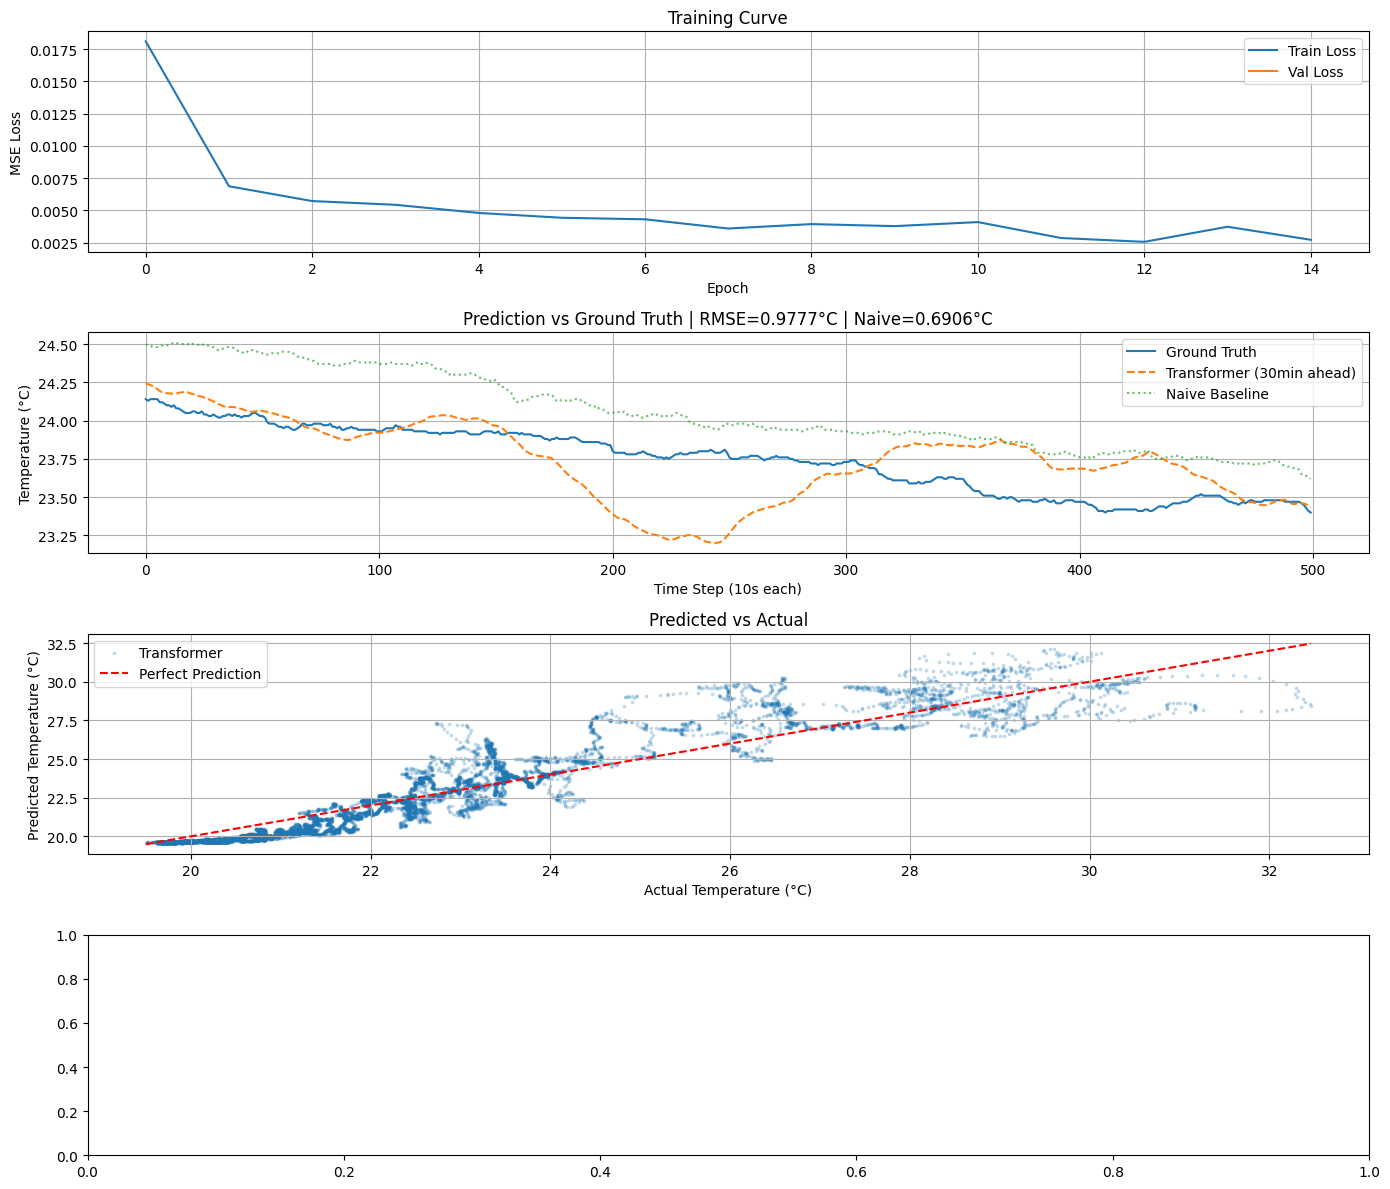

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# 图1：Loss曲线
axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses, label="Val Loss")
axes[0].set_title("Training Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(True)

# 图2：预测 vs 真实
n_show = 500
axes[1].plot(actuals_real[:n_show], label="Ground Truth")
axes[1].plot(preds_real[:n_show], label="Transformer (30min ahead)", linestyle="--")
axes[1].plot(naive_real[:n_show], label="Naive Baseline", linestyle=":", alpha=0.7)
axes[1].set_title(f"Prediction vs Ground Truth | RMSE={rmse:.4f}°C | Naive={rmse_naive:.4f}°C")
axes[1].set_xlabel("Time Step (10s each)")
axes[1].set_ylabel("Temperature (°C)")
axes[1].legend()
axes[1].grid(True)

# 图3：散点图
axes[2].scatter(actuals_real, preds_real, alpha=0.2, s=3, label="Transformer")
axes[2].plot(
    [actuals_real.min(), actuals_real.max()],
    [actuals_real.min(), actuals_real.max()],
    'r--', label="Perfect Prediction"
)
axes[2].set_title("Predicted vs Actual")
axes[2].set_xlabel("Actual Temperature (°C)")
axes[2].set_ylabel("Predicted Temperature (°C)")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()

In [21]:
# 前5个值对比
print("naive_real 前5:", naive_real[:5])
print("actuals/y_true 前5:", actuals_real[:5])  # LSTM用y_true_real
print("差值前5:", (naive_real - actuals_real)[:5])  # LSTM用y_true_real

naive_real 前5: [24.50000005 24.49000013 24.49000013 24.48000021 24.48000021]
actuals/y_true 前5: [24.14000022 24.12999977 24.14000022 24.14000022 24.14000022]
差值前5: [0.35999983 0.36000036 0.34999991 0.33999999 0.33999999]
